# Progetto: relazione tra sonno e performance accademica

Questo progetto richiede di analizzare le abitudini del sonno di un gruppo di studenti universitari per indagarne un'eventuale correlazione con la prestazione agli esami. 
Nota: file rimosso per privacy. 


## ❓Caricare e pulire i dati

**Tasks:**
- Caricare il file `sleep_academic_performance.csv` in un ambiente Python  
- Mostrare il tipo di dati di ogni colonna
- Verificare la presenza di dati mancanti in ciascuna colonna
- Rimuovere le righe contenenti dati mancanti
- Stampare la dimensione del dataset prima e dopo aver rimosso i dati mancanti


In [1]:

#Importo le librerie necessarie
import os 
import pandas as pd 

# Caricare un file chiamato 'sleep_academic_performance.csv' in questa cartella per eseguire il codice.
df=pd.read_csv('sleep_academic_performance.csv') 

#Verifico le informazioni generali del dataframe
#print(df.info()) 

#Mostro esplicitamente il tipo di dato per ogni colonna, anche se era già visibile dal comando precedente (df.info()) 
for colonna in df.columns: 
    print(f'\n La colonna {colonna} contiene dati di questo tipo: {df[colonna].dtype}')

#Verifico la presenza di dati mancanti in ogni colonna 
print('\n',df.isnull().sum())

#Rimuovo le righe contenenti dati mancanti creando un dataframe uguale ma pulito così da poter vedere la differenza
df_clean=df.copy()
df_clean.dropna(inplace=True)   #elimino le righe con dati mancanti direttamente nel nuovo dataframe

#Stampo le dimensioni del dataset prima e dopo la rimozione dei dati mancanti
print('\n Dimesioni prima della pulizia dati:', df.shape)
print('\n Dimensioni dopo la pulizia dati:',df_clean.shape)




 La colonna student_id contiene dati di questo tipo: int64

 La colonna gender contiene dati di questo tipo: object

 La colonna age contiene dati di questo tipo: int64

 La colonna hours_of_sleep contiene dati di questo tipo: float64

 La colonna uses_sleep_tracker contiene dati di questo tipo: bool

 La colonna caffeine_cups_per_day contiene dati di questo tipo: float64

 La colonna exam_score contiene dati di questo tipo: float64

 La colonna study_hours_per_week contiene dati di questo tipo: float64

 La colonna has_sleep_disorder contiene dati di questo tipo: bool

 student_id               0
gender                   0
age                      0
hours_of_sleep           8
uses_sleep_tracker       0
caffeine_cups_per_day    6
exam_score               5
study_hours_per_week     7
has_sleep_disorder       0
dtype: int64

 Dimesioni prima della pulizia dati: (100, 9)

 Dimensioni dopo la pulizia dati: (76, 9)


## 📊 Statistiche descrittive

**Tasks:**
- Calcolare e stampare alcune statistiche descrittive (media, mediana, deviazione standard, min, max) per le seguenti variabili numeriche:
  - `hours_of_sleep`
  - `exam_score`
  - `study_hours_per_week`
- Calcolare e stampare la correlazione tra ore di sonno e punteggio all'esame


In [2]:
#Statistiche descrittive 
df_variabili=df_clean[['hours_of_sleep','exam_score','study_hours_per_week']]    #creo un dataframe in cui includo solo le colonne del dataframe di mio interesse
for colonna in df_variabili.columns:                                             #applico un ciclo for così da non dover riscrivere le statistiche descrittive per ogni colonna 
    print('Statistiche descrittive per',colonna)
    print('Media:',df_variabili[colonna].mean())
    print('Mediana:',df_variabili[colonna].median())
    print('Deviazione standard:',df_variabili[colonna].std())
    print('Minimo:',df_variabili[colonna].min())
    print('Massimo:',df_variabili[colonna].max())
    print('\n')  

#Calcolo la matrice di correlazione
correlazione= df_clean[['hours_of_sleep','exam_score']].corr()  
#Scelgo il valore di intresse della correlazione così da non stampare l'intera matrice e avere valori ripetuti                    
valore_correlazione= correlazione.loc['hours_of_sleep','exam_score'].round(3) 
print('La correlazione tra ore di sonno e punteggio all\'esame è:', valore_correlazione) 


Statistiche descrittive per hours_of_sleep
Media: 6.648684210526315
Mediana: 6.8
Deviazione standard: 1.5666944753037741
Minimo: 4.1
Massimo: 12.3


Statistiche descrittive per exam_score
Media: 75.07105263157897
Mediana: 76.25
Deviazione standard: 11.950116493596466
Minimo: 48.3
Massimo: 100.0


Statistiche descrittive per study_hours_per_week
Media: 21.486842105263158
Mediana: 22.0
Deviazione standard: 8.63557513398713
Minimo: 5.0
Massimo: 34.0


La correlazione tra ore di sonno e punteggio all'esame è: 0.237


## 📈 Visualizzare i dati

**Tasks:**
1. Creare un **bar plot** che mostri il voto medio per genere (Female, Male, Non-binary)  
2. Creare un **istogramma** che mostri la distribuzione delle ore di sonno tra tutti gli studenti


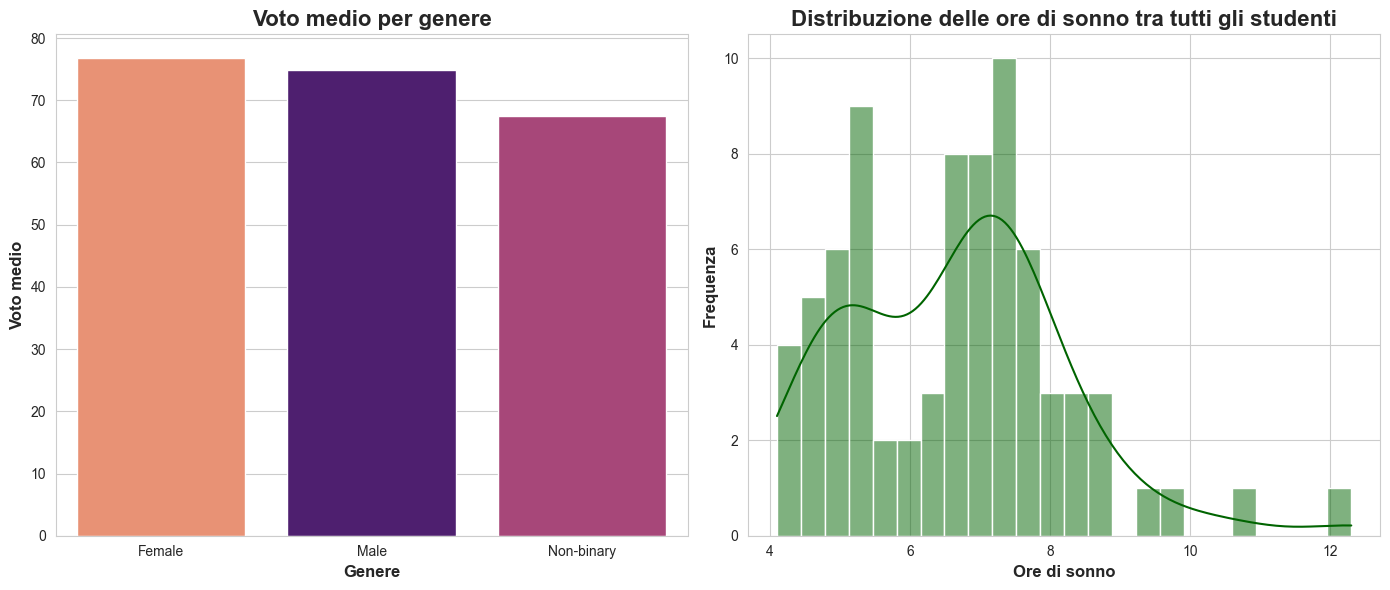

In [3]:
#Importo le librerie necessarie
import seaborn as sns
import matplotlib.pyplot as plt

#Configurazione stile grafici 
sns.set_style("whitegrid")

#Delimito lo spazio in cui poter poi assegnare i due grafici
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Barplot nello spazio di sinistra
#Configuro le caratteristiche del barplot: variabili, colore differenziato per genere, ordine, elimino errorbar e legenda
ordine =['Female','Male','Non-binary'] #inizializzo lista con l'ordine 
sns.barplot(data=df_clean,x='gender',y='exam_score',hue='gender', ax=axes[0], order=ordine, errorbar=None, palette='magma',legend=False)
#Imposto i titoli del grafico e degli assi modificamdo le caratteristiche di grandezza e tipo del font 
axes[0].set_title('Voto medio per genere',fontsize=16,fontweight='bold')  
axes[0].set_xlabel('Genere',fontsize=12,fontweight='semibold')
axes[0].set_ylabel('Voto medio',fontsize=12,fontweight='semibold')

#Istogramma dello spazio di destra
#Configuro le caratterische delll'istogramma: variabili, presenza della linea di densità, scelta degli intervalli di suddivisione, colore del grafico
sns.histplot(data=df_clean,x='hours_of_sleep', bins=24,kde=True, ax=axes[1], color='darkgreen')
#Imposto i titoli del grafico e degli assi modificamdo le caratteristiche di grandezza e tipo del font 
axes[1].set_title('Distribuzione delle ore di sonno tra tutti gli studenti',fontsize=16,fontweight='bold')
axes[1].set_xlabel ('Ore di sonno',fontsize=12,fontweight='semibold')
axes[1].set_ylabel ('Frequenza',fontsize=12,fontweight='semibold') 

#Regolo la disposizione e mostro i grafici
plt.tight_layout()
plt.show()

## 🧮 Filtrare e raggruppare i dati

**Tasks:**
- Trovare tutti gli studenti che dormono almeno 7 ore a notte
- Raggrupparli per genere e calcolare il voto medio all'esame per ciascun gruppo
- Visualizzare (o stampare a video) i risultati

In [4]:
#Studenti che dormono almeno 7 ore 
#Filtro e seleziono dal dataframe gli studento che dormono un numero >=7
studenti_selezionati=df_clean[df_clean['hours_of_sleep']>=7]   

#Conto gli studenti selezionati
#Prima seleziono una colonna specifica del dataframe filtrato perchè altrimenti mi ritornerebbe lo stesso numero per ogni colonna
numero_studenti=studenti_selezionati['student_id'].count()

#Raggruppo per genere e calcolo il voto medio per ogni gruppo
voto_medio_genere= studenti_selezionati.groupby('gender')['exam_score'].mean().round(2) 

print(f'Gli studenti che dormono almeno 7 ore a notte sono {numero_studenti}.')
print('\nIl voto medio per ciascun gruppo di studenti che dormono almeno 7 ore:\n',voto_medio_genere)

Gli studenti che dormono almeno 7 ore a notte sono 34.

Il voto medio per ciascun gruppo di studenti che dormono almeno 7 ore:
 gender
Female        77.49
Male          78.08
Non-binary    67.62
Name: exam_score, dtype: float64


## 🏷️ Creare una nuova colonna

**Task:**
Creare una nuova colonna chiamata `sleep_category` che categorizza gli studenti in base alle ore di sonno che dormono:
- `"Insufficient"` se `hours_of_sleep < 6`
- `"Adequate"` se `6 ≤ hours_of_sleep < 8`
- `"Optimal"` se `hours_of_sleep ≥ 8`


In [5]:
#Creo una funzionne da applicare ad ogni riga del mio dataframe che mi permette di poter categorizzare i dati in base alle ore di sonno 
def ore_sonno(h):
    if h>=8:
        return 'Optimal'
    elif 6<=h<8: 
        return 'Adequate'
    else:
        return 'Insufficient'  

#Creo la nuova categoria applicando la funzione 
df_clean['sleep_category']= df_clean['hours_of_sleep'].apply(ore_sonno)

#Controllo che sia stata applicata correttamente e su tutte e 76 le righe
#print(df_clean['sleep_category'].value_counts())
#print(df_clean['sleep_category'].count()== len(df_clean))



## 💾 Salvare i risultati

**Tasks:**
- Salvare un nuovo DataFrame (pulito dai dati mancanti e con la nuova variabile `sleep_category`) in un nuovo file CSV chiamato  
  **`sleep_analysis_results.csv`**
- Salvare **solamente** le seguenti variabili:
  - `student_id`
  - `gender`
  - `hours_of_sleep`
  - `exam_score`
  - `sleep_category`


In [6]:
#Raccolgo le colonne che mi interessano 
colonne= ['student_id','gender','hours_of_sleep','exam_score','sleep_category']  
#Creo dataframe con solo le colonne selezionate
df_finito=df_clean[colonne]

#Converto in formato CSV e salvo il nuovo file nella wd corrente, senza salvare gli indici perchè in questo caso non è necessario avere una colonna aggiuntiva con i numeri delle righe
df_finito.to_csv('sleep_analysis_results.csv',index=False)

#Controllo che sia stato salvato correttamente
try: 
    file_prova = pd.read_csv('sleep_analysis_results.csv')
    print(file_prova)  
except FileNotFoundError:
    print('Il file non esiste')
except Exception as e: 
    print('Rilevato l\'errore',e) 

    student_id      gender  hours_of_sleep  exam_score sleep_category
0            1        Male             6.2        65.5       Adequate
1            2  Non-binary             7.0        73.9       Adequate
2            3      Female             6.4        78.4       Adequate
3            6        Male             7.6        76.4       Adequate
4            7        Male             7.7        78.4       Adequate
..         ...         ...             ...         ...            ...
71          95      Female             7.3        52.6       Adequate
72          96      Female            12.3        91.3        Optimal
73          97      Female             7.4        62.0       Adequate
74          98      Female             8.2        88.1        Optimal
75          99        Male             7.9        83.6       Adequate

[76 rows x 5 columns]
